In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
import zipfile
import os

extract_path = "/content/newsData"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files extracted successfully")
print(os.listdir(extract_path))

Files extracted successfully
['raw_analyst_ratings.csv']


In [20]:
import pandas as pd

file_path = "/content/newsData/raw_analyst_ratings.csv"

df = pd.read_csv(file_path)
df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [21]:
df.shape
df.columns
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   Unnamed: 0  1407328 non-null  int64 
 1   headline    1407328 non-null  object
 2   url         1407328 non-null  object
 3   publisher   1407328 non-null  object
 4   date        1407328 non-null  object
 5   stock       1407328 non-null  object
dtypes: int64(1), object(5)
memory usage: 64.4+ MB


,0
Unnamed: 0,0
headline,0
url,0
publisher,0
date,0
stock,0


In [22]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["date"].head()

,date
0,2020-06-05 10:30:54-04:00
1,2020-06-03 10:45:20-04:00
2,2020-05-26 04:30:07-04:00
3,2020-05-22 12:45:06-04:00
4,2020-05-22 11:38:59-04:00


In [23]:
df["headline_length"] = df["headline"].astype(str).apply(len)
df["headline_length"].describe()

,headline_length
count,1.407328e+06
mean,7.312051e+01
std,4.073531e+01
min,3.000000e+00
25%,4.700000e+01
50%,6.400000e+01
75%,8.700000e+01
max,5.120000e+02


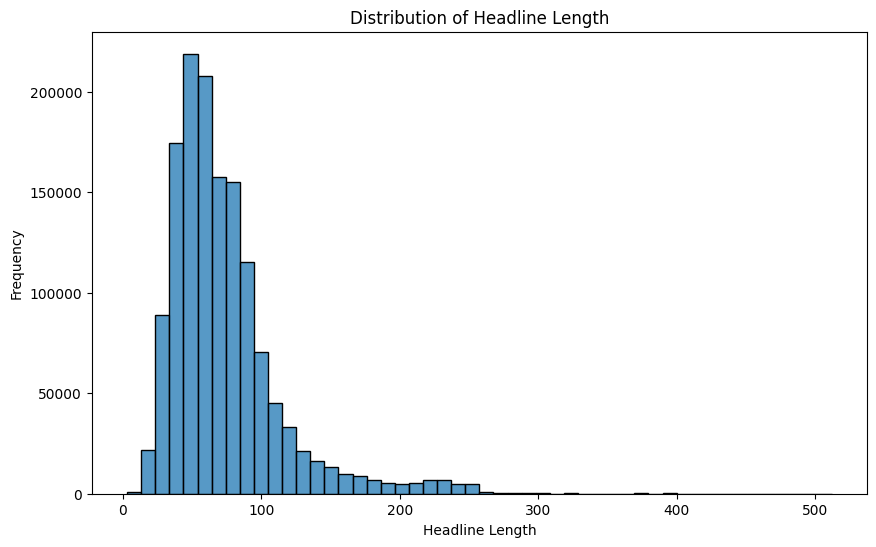

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(df["headline_length"], bins=50)
plt.title("Distribution of Headline Length")
plt.xlabel("Headline Length")
plt.ylabel("Frequency")
plt.show()

In [25]:
top_publishers = df["publisher"].value_counts().head(20)
top_publishers

,count
publisher,
Paul Quintaro,228373
Lisa Levin,186979
Benzinga Newsdesk,150484
Charles Gross,96732
Monica Gerson,82380
Eddie Staley,57254
Hal Lindon,49047
ETF Professor,28489
Juan Lopez,28438


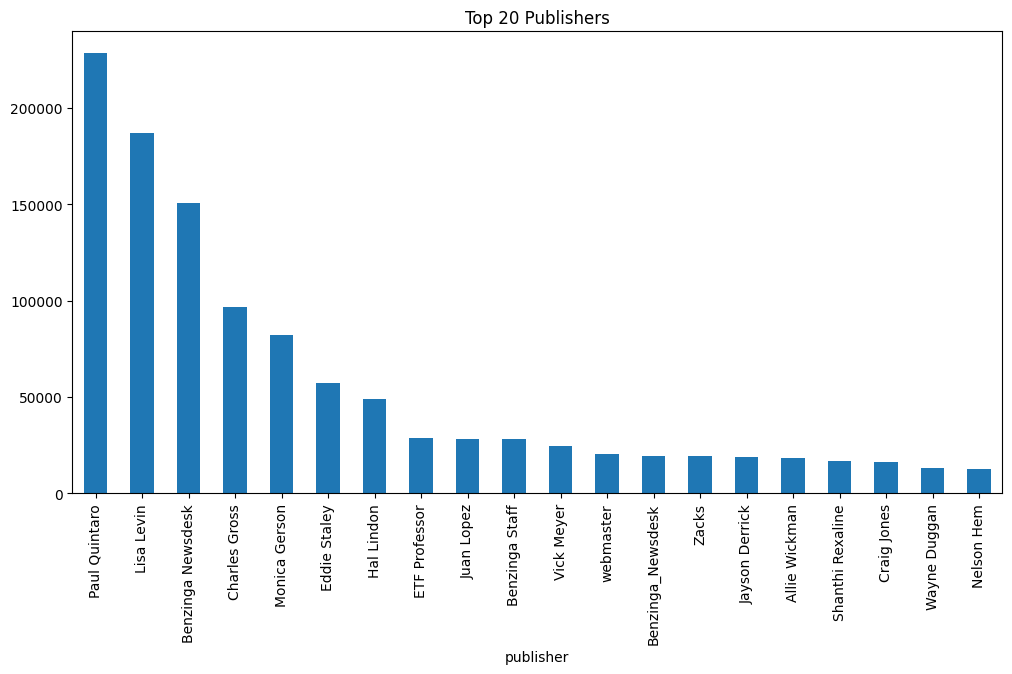

In [26]:
top_publishers.plot(kind="bar", figsize=(12,6))
plt.title("Top 20 Publishers")
plt.show()

In [27]:
daily_news = df.groupby(df["date"].dt.date).size()
daily_news.head()

,0
date,
2011-04-27,1
2011-04-28,2
2011-04-29,2
2011-04-30,1
2011-05-01,1


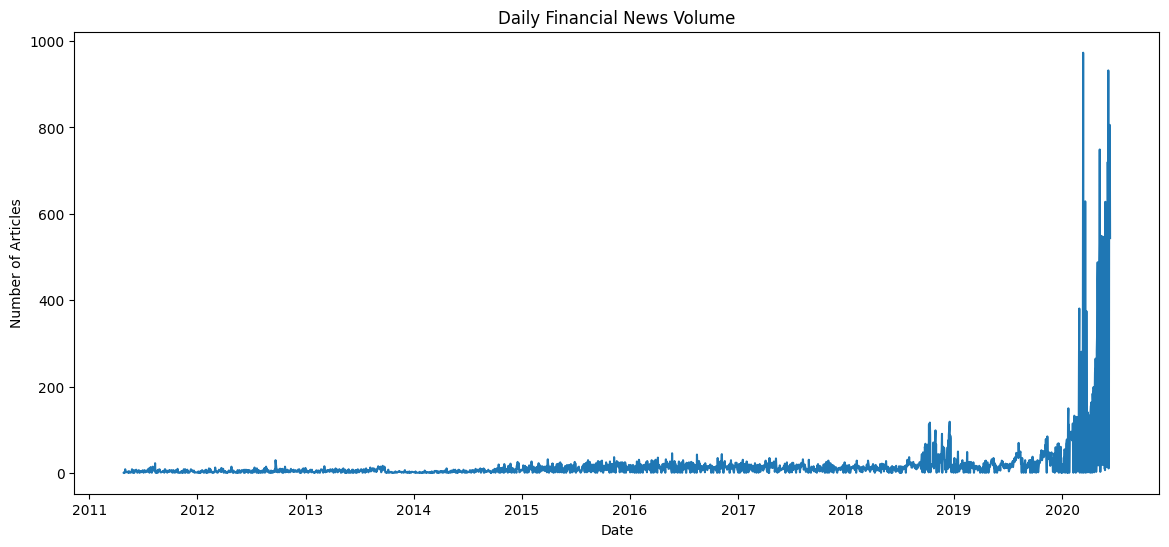

In [28]:
daily_news.plot(figsize=(14,6))
plt.title("Daily Financial News Volume")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.show()

In [29]:
df["hour"] = df["date"].dt.hour
df["hour"].value_counts().sort_index()

,count
hour,
0.0,67
1.0,14
2.0,57
3.0,93
4.0,1469
5.0,1829
6.0,2476
7.0,5033
8.0,5527


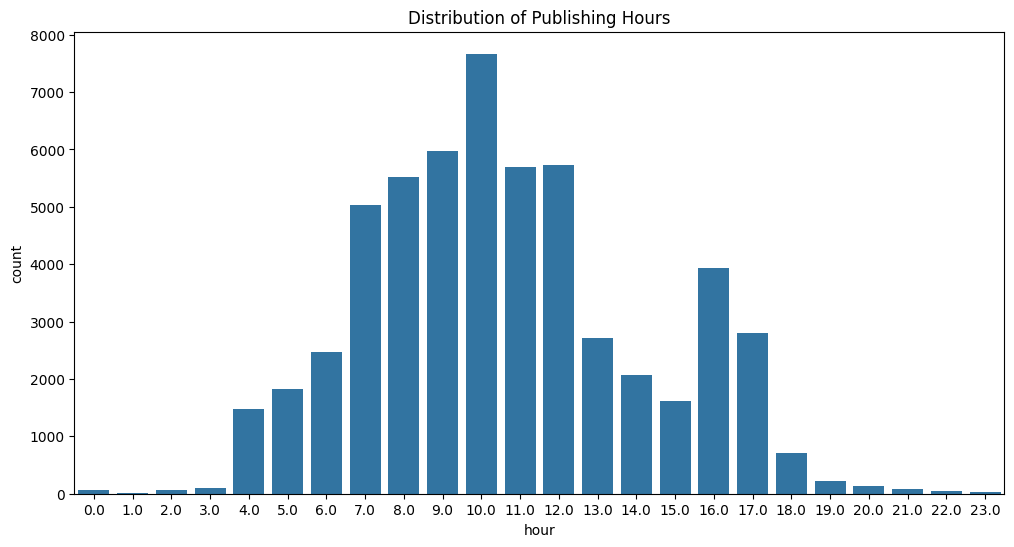

In [30]:
plt.figure(figsize=(12,6))
sns.countplot(x="hour", data=df)
plt.title("Distribution of Publishing Hours")
plt.show()

In [31]:
df["hour"] = df["date"].dt.hour

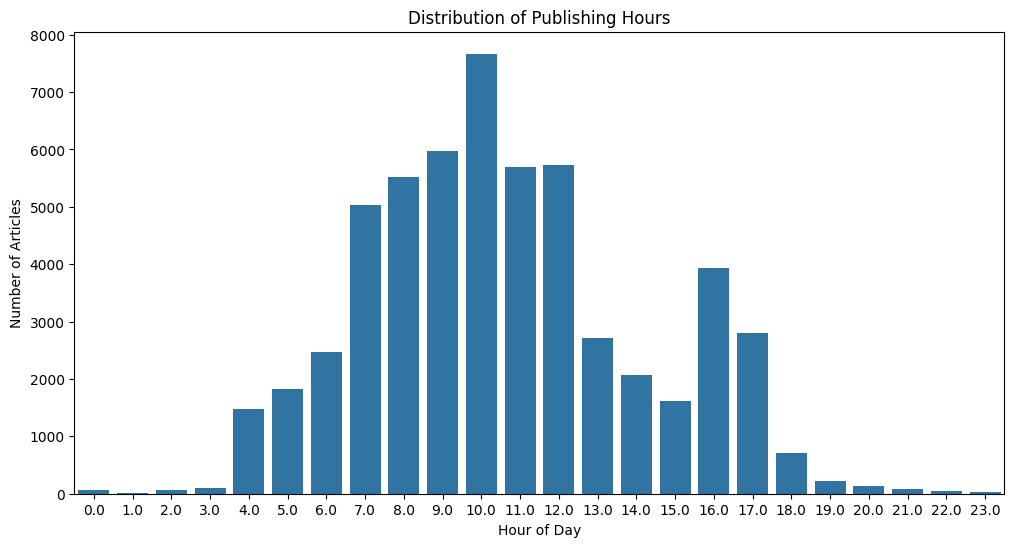

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.countplot(x="hour", data=df)
plt.title("Distribution of Publishing Hours")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Articles")
plt.show()

In [33]:
sample_df = df.sample(50000, random_state=42)
sample_df.shape

(50000, 8)

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=20
)

X = vectorizer.fit_transform(sample_df["headline"].astype(str))

keywords = vectorizer.get_feature_names_out()

print("Top Keywords:")
print(keywords)

Top Keywords:
['52' 'announces' 'benzinga' 'buy' 'downgrades' 'earnings' 'eps' 'est'
 'market' 'mid' 'price' 'pt' 'reports' 'sales' 'shares' 'stocks' 'trading'
 'update' 'vs' 'week']


In [35]:
df[df["publisher"].str.contains("@", na=False)].head()

,Unnamed: 0,headline,url,publisher,date,stock,headline_length,hour
5,5,"CFRA Maintains Hold on Agilent Technologies, L...",https://www.benzinga.com/news/20/05/16095163/c...,vishwanath@benzinga.com,2020-05-22 11:23:25-04:00,A,71,11.0
6,6,"UBS Maintains Neutral on Agilent Technologies,...",https://www.benzinga.com/news/20/05/16094027/u...,vishwanath@benzinga.com,2020-05-22 09:36:20-04:00,A,73,9.0
8,8,Wells Fargo Maintains Overweight on Agilent Te...,https://www.benzinga.com/news/20/05/16093505/w...,vishwanath@benzinga.com,2020-05-22 08:37:59-04:00,A,84,8.0
11,11,SVB Leerink Maintains Outperform on Agilent Te...,https://www.benzinga.com/news/20/05/16092270/s...,vishwanath@benzinga.com,NaT,A,84,NaN
22,22,"UBS Maintains Neutral on Agilent Technologies,...",https://www.benzinga.com/news/20/04/15897306/u...,vishwanath@benzinga.com,NaT,A,73,NaN


In [36]:
df["domain"] = df["publisher"].str.extract(r'@(.+)')
df["domain"].value_counts().head(20)

,count
domain,
benzinga.com,7937
gmail.com,139
andyswan.com,5
investdiva.com,2
tothetick.com,2
eosdetroit.io,1
forextraininggroup.com,1
stockmetrix.net,1
